In [18]:
TP = 53
FN = 17
FP = 59
TN = 871

print("TP =", TP)
print("FN =", FN)
print("FP =", FP)
print("TN =", TN)

TP = 53
FN = 17
FP = 59
TN = 871


In [19]:
total = TP + FN + FP + TN

print("Всего объектов:", total)

Всего объектов: 1000


In [20]:
total = TP + FN + FP + TN

print("Всего объектов:", total)

Всего объектов: 1000


In [21]:
import numpy as np

matrix = np.array([
    [TN, FP],
    [FN, TP]
])

print(matrix)

[[871  59]
 [ 17  53]]


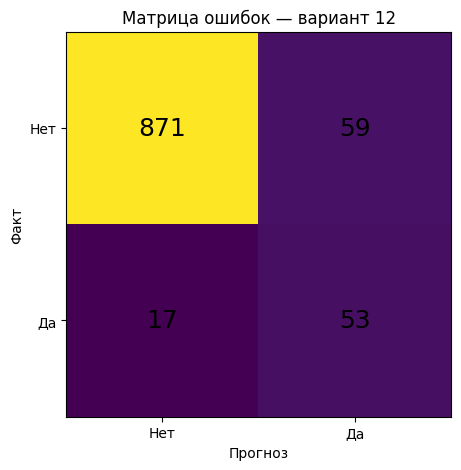

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(matrix)

plt.xticks([0, 1], ["Нет", "Да"])
plt.yticks([0, 1], ["Нет", "Да"])

plt.xlabel("Прогноз")
plt.ylabel("Факт")
plt.title("Матрица ошибок — вариант 12")

for i in range(2):
    for j in range(2):
        plt.text(j, i, matrix[i, j],
                 ha="center", va="center",
                 fontsize=18)

plt.show()

In [23]:
accuracy = (TP + TN) / total

print("Accuracy =", round(accuracy, 3))

Accuracy = 0.924


In [24]:
precision = TP / (TP + FP)

print("Precision =", round(precision, 3))

Precision = 0.473


In [25]:
recall = TP / (TP + FN)

print("Recall =", round(recall, 3))

Recall = 0.757


In [26]:
specificity = TN / (TN + FP)

print("Specificity =", round(specificity, 3))

Specificity = 0.937


In [27]:
f1 = 2 * precision * recall / (precision + recall)

print("F1 =", round(f1, 3))

F1 = 0.582


In [28]:
print("Результаты модели:")
print("-------------------")
print("Accuracy   =", round(accuracy, 3))
print("Precision  =", round(precision, 3))
print("Recall     =", round(recall, 3))
print("Specificity =", round(specificity, 3))
print("F1         =", round(f1, 3))

Результаты модели:
-------------------
Accuracy   = 0.924
Precision  = 0.473
Recall     = 0.757
Specificity = 0.937
F1         = 0.582


In [29]:
accuracy_always_no = TN + FN

accuracy_always_no = accuracy_always_no / total

print("Accuracy модели:", round(accuracy, 3))
print("Accuracy модели 'всегда нет':", round(accuracy_always_no, 3))

Accuracy модели: 0.924
Accuracy модели 'всегда нет': 0.888


In [30]:
TP_new = TP + 11
FN_new = FN - 11

TN_new = TN - 26
FP_new = FP + 26

print("Новая матрица:")
print("TP =", TP_new)
print("FN =", FN_new)
print("FP =", FP_new)
print("TN =", TN_new)

Новая матрица:
TP = 64
FN = 6
FP = 85
TN = 845


In [31]:
precision_new = TP_new / (TP_new + FP_new)
recall_new = TP_new / (TP_new + FN_new)

f1_new = 2 * precision_new * recall_new / (precision_new + recall_new)

print("Новые метрики:")
print("Precision =", round(precision_new, 3))
print("Recall    =", round(recall_new, 3))
print("F1        =", round(f1_new, 3))

Новые метрики:
Precision = 0.43
Recall    = 0.914
F1        = 0.584


In [32]:
print("Сравнение до и после изменения порога")
print("--------------------------------------")

print("Precision:", round(precision, 3), "->", round(precision_new, 3))
print("Recall:   ", round(recall, 3), "->", round(recall_new, 3))
print("F1:       ", round(f1, 3), "->", round(f1_new, 3))

Сравнение до и после изменения порога
--------------------------------------
Precision: 0.473 -> 0.43
Recall:    0.757 -> 0.914
F1:        0.582 -> 0.584


In [33]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = (
    [1] * 53 +
    [1] * 17 +
    [0] * 59 +
    [0] * 871
)

y_pred = (
    [1] * 53 +
    [0] * 17 +
    [1] * 59 +
    [0] * 871
)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Confusion Matrix:
[[871  59]
 [ 17  53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       930
           1       0.47      0.76      0.58        70

    accuracy                           0.92      1000
   macro avg       0.73      0.85      0.77      1000
weighted avg       0.95      0.92      0.93      1000



In [34]:
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import balanced_accuracy_score

mcc = matthews_corrcoef(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)

print("MCC =", round(mcc, 3))
print("Balanced Accuracy =", round(balanced_acc, 3))

MCC = 0.561
Balanced Accuracy = 0.847
